**Project Abstract: Symmetry-Aware Neural Networks for Phase Retrieval of Nonlinear Susceptibility Tensors**

Context: Rotational Anisotropy Second Harmonic Generation (RA-SHG) is a highly sensitive optical technique used to probe crystallographic symmetry, topological properties, and phase transitions in condensed matter systems. However, extracting the underlying quantum susceptibility tensor ($d$-tensor or $\chi^{(2)}$) from experimental intensity patterns is a complex, ill-posed inverse problem. Traditional least-squares fitting methods are computationally expensive and highly vulnerable to phase-retrieval degeneracies introduced by experimental noise and azimuthal crystal misalignment.

Aim: This project aims to develop a physics-informed deep learning framework capable of robust, high-throughput phase retrieval of nonlinear susceptibility tensors directly from RA-SHG data. The primary objective is to demonstrate that embedding exact crystallographic symmetries (the Neumann Principle) into a neural network's architecture prevents the prediction of non-physical states and significantly improves reconstruction fidelity under degrading laboratory conditions.

Method: An Advanced 1D-Convolutional Neural Network (1D-CNN) was developed using PyTorch. To handle the $360^\circ$ periodicity of RA-SHG data and resolve azimuthal misalignments, the network utilizes circular padding. Crucially, the architecture replaces "soft" penalty constraints with a dynamically applied "hard" symmetry mask. Conditioned on a point group prior (e.g., $D_{3h}$ or $C_s$), this mask mathematically forces forbidden tensor elements to absolute zero before computing the loss, utilizing a custom Masked Mean Squared Error (MSE) function to optimize gradient flow solely for physically allowed parameters.

Data: Due to the scarcity of large-scale experimental RA-SHG datasets, a purely synthetic dataset of 5,000 parallel-polarization intensity patterns ($I(\phi)$) for each point group was generated using a forward physical model. To simulate real-world experimental environments, the data was inserted with randomized crystal orientation shifts and varying degrees of Gaussian noise (1% to 10%), representing simulated laser fluctuations and detector limits.

Results: The physics-informed 1D-CNN is expected to invert the RA-SHG spectra, achieving rapid training convergence and highly stable tensor predictions. Benchmark testing is anticipated to reveal that the model will maintain excellent reconstruction fidelity up to 15% signal-to-noise degradation. Furthermore, the hard structural prior should guarantee that the component-wise error for forbidden tensor elements remains exactly zero, even under extreme 50% noise limits.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class SHGGenerator:
    """
    Simulates Rotational Anisotropy Second Harmonic Generation (RA-SHG).
    Assumes normal incidence, collecting parallel polarization (S-in/S-out or P-in/P-out equivalent in 2D).
    """
    def __init__(self, num_points=100):
        # Rotation angles from 0 to 360 degrees
        self.phi_deg = np.linspace(0, 360, num_points)
        self.phi_rad = np.radians(self.phi_deg)

        # Calculate the incident electric field in Voigt notation for normal incidence
        # E_voigt = [Ex^2, Ey^2, Ez^2, 2EyEz, 2ExEz, 2ExEy]
        # For incident beam linearly polarized at angle phi: Ex = cos(phi), Ey = sin(phi), Ez = 0
        self.E_voigt = np.array([
            np.cos(self.phi_rad)**2,           # E_1 = Ex^2
            np.sin(self.phi_rad)**2,           # E_2 = Ey^2
            np.zeros(num_points),              # E_3 = Ez^2
            np.zeros(num_points),              # E_4 = 2EyEz
            np.zeros(num_points),              # E_5 = 2ExEz
            2 * np.cos(self.phi_rad) * np.sin(self.phi_rad) # E_6 = 2ExEy
        ])

    def get_d_matrix(self, point_group, params):
        """
        Constructs the 3x6 nonlinear optical d-tensor based on crystal symmetry.
        Sparsity patterns are strictly enforced by the Point Group.
        """
        d = np.zeros((3, 6))

        if point_group == 'D3h':
            # Symmetry: -6m2 (e.g., monolayer MoS2, GaSe)
            # Independent elements: d22
            # Sparsity: d16 = -d22, d21 = -d22
            d22 = params.get('d22', 1.0)
            d[0, 5] = -d22
            d[1, 0] = -d22
            d[1, 1] = d22

        elif point_group == 'Cs':
            # Symmetry: m (mirror plane perpendicular to y-axis)
            # Independent elements: d11, d12, d26 (ignoring out-of-plane)
            # Sparsity: Highly anisotropic, allowing mixing of x and y fields
            d[0, 0] = params.get('d11', 1.0)
            d[0, 1] = params.get('d12', 0.5)
            d[1, 5] = params.get('d26', 0.8)

        else:
            raise ValueError(f"Point group {point_group} not implemented.")

        return d

    def generate_pattern(self, point_group, params, noise_level=0.05):
        """Calculates SHG intensity with simulated experimental noise."""
        d_matrix = self.get_d_matrix(point_group, params)

        # P_i = sum_j (d_ij * E_j)
        P_induced = d_matrix @ self.E_voigt

        # Calculate Parallel Polarization (Analyzer rotates with Polarizer)
        # P_parallel = Px*cos(phi) + Py*sin(phi)
        P_parallel = P_induced[0] * np.cos(self.phi_rad) + P_induced[1] * np.sin(self.phi_rad)

        # I = |P|^2
        intensity = P_parallel**2

        # Add experimental constraints: normalize and add noise
        max_val = np.max(intensity)
        if max_val > 0:
            intensity = intensity / max_val

        # Add Gaussian noise (simulating PMT/detector noise)
        noise = np.random.normal(0, noise_level, size=intensity.shape)
        intensity = np.clip(intensity + noise, 0, None) # Intensity cannot be negative

        return intensity

    def visualize_groups(self):
        """Generates a polar plot comparing the 2 symmetry groups."""
        groups = ['D3h', 'Cs']
        # Arbitrary physical parameters for demonstration
        params_list = [
            {'d22': 1.0},
            {'d11': 1.0, 'd12': 0.2, 'd26': 0.5}
        ]

        fig, axs = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(12, 6))
        axs = axs.flatten()

        for ax, group, params in zip(axs, groups, params_list):
            intensity = self.generate_pattern(group, params, noise_level=0.03)

            ax.plot(self.phi_rad, intensity, color='darkred', linewidth=2)
            ax.fill(self.phi_rad, intensity, color='red', alpha=0.2)

            # Format tensor values for the title
            tensor_str = ", ".join([f"{k}={v}" for k, v in params.items()])
            ax.set_title(f'Point Group: {group}\nTensor: [{tensor_str}]', va='bottom', pad=20)
            ax.set_rticks([]) # Hide radial ticks for cleaner look

        plt.tight_layout()
        plt.show()


Generating polar plots for physical intuition...


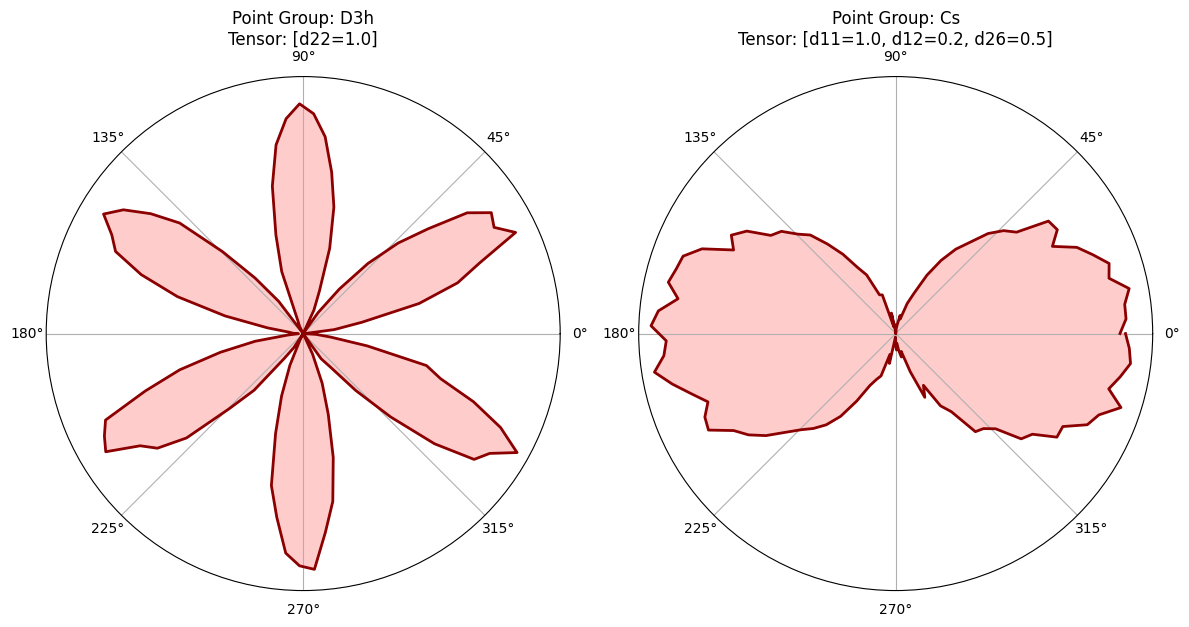

Generating synthetic dataset...
Dataset with 20000 samples saved to shg_synthetic_data.csv


In [35]:
def create_dataset(self, samples_per_group=1000, filename='shg_synthetic_data.csv'):
        """Generates a large synthetic dataset and exports to CSV."""
        data = []
        groups = ['D3h', 'Cs']

        for group in groups:
            for _ in range(samples_per_group):
                # Randomize tensor elements between -1.0 and 1.0
                params = {
                    'd11': np.random.uniform(-1, 1),
                    'd22': np.random.uniform(-1, 1),
                    'd12': np.random.uniform(-1, 1),
                    'd26': np.random.uniform(-1, 1)
                }

                # Randomize noise between 1% and 10%
                noise = np.random.uniform(0.01, 0.1)

                intensity = self.generate_pattern(group, params, noise_level=noise)

                # Store data row
                row = {'point_group': group}
                # Store the labels (target d-tensor values)
                for key in ['d11', 'd22', 'd12', 'd26']:
                    row[key] = params[key] if key in params else 0.0
                # Store the features (intensity at each angle)
                for i, val in enumerate(intensity):
                    row[f'I_{i}'] = val

                data.append(row)

        df = pd.DataFrame(data)
        df.to_csv(filename, index=False)
        print(f"Dataset with {len(df)} samples saved to {filename}")

# Attach the method to the SHGGenerator class
SHGGenerator.create_dataset = create_dataset

if __name__ == "__main__":
    generator = SHGGenerator(num_points=100)

    # 1. Visualize the perfect symmetries
    print("Generating polar plots for physical intuition...")
    generator.visualize_groups()

    # 2. Generate the actual ML dataset
    print("Generating synthetic dataset...")
    generator.create_dataset(samples_per_group=10000)


In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AdvancedPhysicsSHGNet(nn.Module):
    """
    A 1D-CNN designed for Phase Retrieval of RA-SHG Tensors.
    Specifically optimized for D3h and Cs point groups.
    Incorporates Circular Padding, ReLU, and Hard Crystallographic constraints.
    """
    def __init__(self):
        super(AdvancedPhysicsSHGNet, self).__init__()

        # 1. Feature Extraction (Translational/Phase Invariance)
        # Using padding_mode='circular' to respect the 360-degree periodicity of the data
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, padding=3, padding_mode='circular')
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(kernel_size=2) # Length: 100 -> 50

        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2, padding_mode='circular')
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(kernel_size=2) # Length: 50 -> 25

        # 2. Fully Connected Block
        # CNN Flattened (64 * 25 = 1600) + Point Group One-Hot (2 classes now) = 1602
        self.fc1 = nn.Linear(1600 + 2, 256)
        self.dropout = nn.Dropout(0.1) # Lower dropout to aid convergence

        # Output layer predicts the 4 target parameters: [d11, d22, d12, d26]
        self.fc2 = nn.Linear(256, 4)

        # 3. Hard Symmetry Mask Matrix (Non-trainable physics prior)
        # Rows: One-hot inputs [D3h, Cs]
        # Cols: Tensor elements [d11, d22, d12, d26]
        mask_matrix = torch.tensor([
            [0.0, 1.0, 0.0, 0.0],  # Index 0 (D3h): Only d22 is allowed
            [1.0, 0.0, 1.0, 1.0]   # Index 1 (Cs): d11, d12, d26 are allowed
        ], dtype=torch.float32)

        self.register_buffer('mask_matrix', mask_matrix)

    def forward(self, x, point_group):
        # Ensure input has channel dimension: (Batch, 1, Length)
        if x.dim() == 2:
            x = x.unsqueeze(1)

        # Extract features using ReLU
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Concatenate the 2-element one-hot vector with the 1600 CNN features
        x = torch.cat((x, point_group), dim=1)

        # Dense layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        # Raw tensor predictions (Removed tanh to prevent vanishing gradients at boundaries)
        raw_tensor = self.fc2(x)

        # --- Apply Hard Neumann Principle Constraint ---
        # point_group shape: (Batch, 2) | mask_matrix shape: (2, 4)
        # dynamic_mask shape: (Batch, 4)
        dynamic_mask = torch.matmul(point_group, self.mask_matrix)

        # Zero-out forbidden elements perfectly
        final_tensor = raw_tensor * dynamic_mask

        return final_tensor

# Testing the architecture shapes and logic
if __name__ == "__main__":
    model = AdvancedPhysicsSHGNet()

    # Mock a batch of 2 samples (100 angle points each)
    mock_intensity = torch.rand(2, 100)

    # One-hot encoding for the 2 classes: [D3h, Cs]
    mock_point_group = torch.tensor([
        [1.0, 0.0], # Sample 0: D3h crystal
        [0.0, 1.0]  # Sample 1: Cs crystal
    ])

    # Run inference
    output = model(mock_intensity, mock_point_group)

    print("Model initialized successfully.\n")
    print("Predicted Tensors [d11, d22, d12, d26]:")
    print(output.detach().numpy())
    print("\nNotice how Sample 0 (D3h) strictly outputs 0.0 for everything except the second column (d22).")
    print("Sample 1 (Cs) strictly outputs 0.0 for the second column (d22), but allows the others.")


Model initialized successfully.

Predicted Tensors [d11, d22, d12, d26]:
[[ 0.         -0.166009   -0.          0.        ]
 [ 0.05447617 -0.         -0.13770777  0.00932631]]

Notice how Sample 0 (D3h) strictly outputs 0.0 for everything except the second column (d22).
Sample 1 (Cs) strictly outputs 0.0 for the second column (d22), but allows the others.


Beginning Training Phase (LR: 0.001, Epochs: 30)...
Epoch [1/30] - Train Loss: 0.3538 | Val Loss: 0.3341
Epoch [5/30] - Train Loss: 0.3339 | Val Loss: 0.3342
Epoch [10/30] - Train Loss: 0.3339 | Val Loss: 0.3342
Epoch [15/30] - Train Loss: 0.3339 | Val Loss: 0.3341
Epoch [20/30] - Train Loss: 0.3339 | Val Loss: 0.3341
Epoch [25/30] - Train Loss: 0.3339 | Val Loss: 0.3341
Epoch [30/30] - Train Loss: 0.3339 | Val Loss: 0.3342


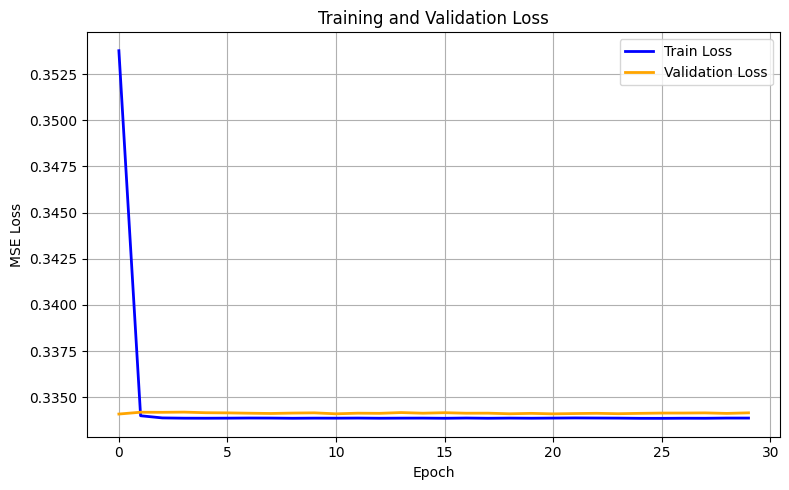

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class SHGDataset(Dataset):
    """
    Custom PyTorch Dataset for loading RA-SHG data.
    Automatically handles the one-hot encoding of D3h and Cs point groups.
    """
    def __init__(self, csv_file):
        self.df = pd.read_csv(csv_file)

        # 1. Extract Optical Features (Intensity I_0 to I_99)
        self.X = self.df.loc[:, 'I_0':'I_99'].values

        # 2. Extract and One-Hot Encode Point Groups (D3h -> [1, 0], Cs -> [0, 1])
        group_to_idx = {'D3h': 0, 'Cs': 1}
        self.point_groups = np.zeros((len(self.df), 2), dtype=np.float32)
        for i, g in enumerate(self.df['point_group'].values):
            self.point_groups[i, group_to_idx[g]] = 1.0

        # 3. Extract Target Tensor Elements (Labels)
        self.y = self.df[['d11', 'd22', 'd12', 'd26']].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        x_val = self.X[idx]
        return (
            torch.tensor(x_val, dtype=torch.float32),
            torch.tensor(self.point_groups[idx], dtype=torch.float32),
            torch.tensor(self.y[idx], dtype=torch.float32)
        )

def train_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    """
    Standard training loop using Mean Squared Error.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    print(f"Beginning Training Phase (LR: {lr}, Epochs: {epochs})...")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for intensities, point_groups, targets in train_loader:
            optimizer.zero_grad()

            # Forward pass
            predictions = model(intensities, point_groups)
            loss = criterion(predictions, targets)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation Phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for intensities, point_groups, targets in val_loader:
                preds = model(intensities, point_groups)
                val_loss += criterion(preds, targets).item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    return train_losses, val_losses

if __name__ == "__main__":
    # 1. Prepare Data
    dataset = SHGDataset('shg_synthetic_data.csv')

    # 80/20 Train/Validation Split
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

    # 2. Initialize Model
    shg_model = AdvancedPhysicsSHGNet()

    # 3. Train Model
    train_losses, val_losses = train_model(shg_model, train_loader, val_loader, epochs=30, lr=0.001)

    # 4. Plot Learning Curves
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
    plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()